In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from optuna.visualization.matplotlib import plot_optimization_history
from optuna.visualization.matplotlib import plot_param_importances

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s15t3_exoplanet.csv')

print(f"Размер выборки: {df.shape}")

print("\nИнформация о выборке:")
print(df.info())

print("\nПервые строки:")
print(df.head())

print()
print(df['label'].value_counts())

Размер выборки: (753, 17)

Информация о выборке:
<class 'pandas.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pc1             753 non-null    float64
 1   pc2             753 non-null    float64
 2   pc3             753 non-null    float64
 3   ra              753 non-null    float64
 4   dec             753 non-null    float64
 5   j_mag           753 non-null    float64
 6   h_mag           753 non-null    float64
 7   k_mag           753 non-null    float64
 8   kep_mag         753 non-null    float64
 9   planet_radius   753 non-null    float64
 10  orbital_period  753 non-null    float64
 11  star_teff       753 non-null    float64
 12  star_logg       753 non-null    float64
 13  star_radius     753 non-null    float64
 14  star_mass       753 non-null    float64
 15  lc_time0        753 non-null    float64
 16  label           753 non-null    int64  
dt

### Разделение выборки

In [3]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=627
)
print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер обучающей выборки: (602, 16)
Размер тестовой выборки: (151, 16)


### Обучение Random Forest

In [4]:
model_rf = RandomForestClassifier(
  n_estimators=100,
  random_state=6271
) # Создайте модель

model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(f"Качество модели на тестовых данных:", accuracy_score(y_test, y_pred))

Качество модели на тестовых данных: 0.6688741721854304


### Сравнение с бэггингом и деревом решений

In [ ]:
# 1. Дерево решений
model_tree = DecisionTreeClassifier(random_state=6271)

# 2. Бэггинг с деревьями решений
model_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=6271),
    n_estimators=100,
    random_state=6271,
)
# 3. Случайный лес
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=6271,
)
# Обучите все три модели
model_tree.fit(X_train, y_train)
model_bagging.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Получите предсказание
y_pred_test_tree = model_tree.predict(X_test)
y_pred_test_bagging = model_bagging.predict(X_test)
y_pred_test_rf = model_rf.predict(X_test)

# Посчитайте качество
accuracy_score_tree = accuracy_score(y_test, y_pred_test_tree)
accuracy_score_bagging = accuracy_score(y_test, y_pred_test_bagging)
accuracy_score_rf = accuracy_score(y_test, y_pred_test_rf)

# 4. Вывод результата
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Random Forest'],
    'Test accuracy': [accuracy_score_tree, accuracy_score_bagging, accuracy_score_rf]
})
print(results)

           Model  Test accuracy
0  Decision Tree       0.529801
1        Bagging       0.629139
2  Random Forest       0.668874


### Оценка разделения

d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(
d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


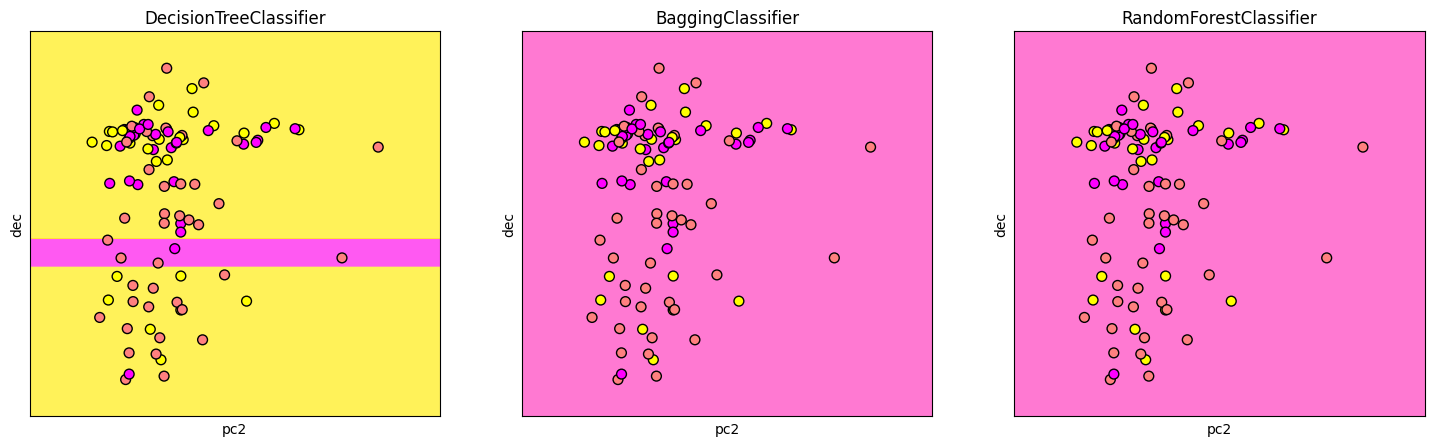

In [6]:
# Функция для отрисовки графика
def plot_cl_ax(ax, title, model, X_train, y_train, col1, col2):
    # Вспомогательная функция для определения границ
    def make_meshgrid(x, y, h=.02):
        step = 0.5
        x_min, x_max = x.min() - step, x.max() + step
        y_min, y_max = y.min() - step, y.max() + step
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        return xx, yy

    # Вспомогательная функция для определения контуров классов
    def plot_contours(ax, model, xx, yy, X_train_full, col1_idx, col2_idx, **params):
        # Создаем сетку предсказаний с правильным количеством признаков
        n_samples = xx.size
        # Получаем индексы колонок
        col1_full = X_train_full.iloc[:, col1_idx].values
        col2_full = X_train_full.iloc[:, col2_idx].values
        
        # Создаем полную сетку с теми же значениями для других признаков (берем медианы)
        X_mesh = np.zeros((n_samples, X_train_full.shape[1]))
        
        # Заполняем значениями для col1 и col2 из сетки
        X_mesh[:, col1_idx] = xx.ravel()
        X_mesh[:, col2_idx] = yy.ravel()
        
        # Для остальных признаков используем медианные значения из обучающей выборки
        for i in range(X_train_full.shape[1]):
            if i != col1_idx and i != col2_idx:
                X_mesh[:, i] = np.median(X_train_full.iloc[:, i])
        
        # Делаем предсказания
        Z = model.predict(X_mesh)
        Z = Z.reshape(xx.shape)
        out = ax.contourf(xx, yy, Z, **params)
        return out

    # Получаем индексы колонок
    col1_idx = list(X_train.columns).index(col1)
    col2_idx = list(X_train.columns).index(col2)
    
    X0, X1 = X_train[col1], X_train[col2] 
    xx, yy = make_meshgrid(X0, X1)

    # Визуализируем разделение пространства между классами
    plot_contours(ax, model, xx, yy, X_train, col1_idx, col2_idx, cmap='spring', alpha=0.7)
    
    # Добавляем точки (только для выбранных признаков)
    ax.scatter(X0, X1, c=y_train, cmap='spring', s=50, edgecolors='k')
    
    # Настраиваем график
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

# Сохраним обученные модели в список
models = {
    "DecisionTreeClassifier": model_tree, 
    "BaggingClassifier": model_bagging, 
    "RandomForestClassifier": model_rf
}

# Создадим поле нескольких графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Построим график для каждой модели. Для наглядности возьмём только первые 100 точек
for ax, (model_name, model) in zip(axes, models.items()):
    plot_cl_ax(ax, model_name, model, X_train[:100], y_train[:100], 'pc2', 'dec')

plt.show()

### Настройка гиперпараметров с Optuna

In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 200),
        'max_depth': trial.suggest_int('max_depth', 20, 30),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'max_samples': trial.suggest_float('max_samples', 0.7, 1.0)
    }

    model = RandomForestClassifier(
        **params,
        random_state=627
    )
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted'
    )

    return scores.mean()

In [ ]:
sampler = optuna.samplers.TPESampler(seed=627)
study = optuna.create_study(sampler=sampler, direction='maximize')
study.optimize(objective, n_trials=25)

best_params = study.best_params
print(f"Лучшие гиперпараметры: {best_params}")
best_value = study.best_value
print(f"Лучшее значение f1_weighted: {best_value:.3f}")

[I 2026-07-03 15:18:13,386] A new study created in memory with name: no-name-5642372b-57c1-4c04-a5f7-29fcafd873c0
[I 2026-07-03 15:18:17,113] Trial 0 finished with value: 0.6927787924153058 and parameters: {'n_estimators': 160, 'max_depth': 24, 'max_features': None, 'max_samples': 0.7697865538914032}. Best is trial 0 with value: 0.6927787924153058.
[I 2026-07-03 15:18:19,067] Trial 1 finished with value: 0.6964714143755805 and parameters: {'n_estimators': 175, 'max_depth': 20, 'max_features': 'sqrt', 'max_samples': 0.9438463324394519}. Best is trial 1 with value: 0.6964714143755805.
[I 2026-07-03 15:18:23,630] Trial 2 finished with value: 0.696948846414425 and parameters: {'n_estimators': 188, 'max_depth': 23, 'max_features': None, 'max_samples': 0.8821561512429321}. Best is trial 2 with value: 0.696948846414425.
[I 2026-07-03 15:18:25,762] Trial 3 finished with value: 0.6996795134303302 and parameters: {'n_estimators': 197, 'max_depth': 23, 'max_features': 'log2', 'max_samples': 0.888

Лучшие гиперпараметры: {'n_estimators': 194, 'max_depth': 27, 'max_features': 'sqrt', 'max_samples': 0.8576849780472598}
Лучшее значение f1_weighted: 0.704


### Обучение модели с лучшими гиперпараметрами

In [ ]:
best_model = RandomForestClassifier(
    **best_params,
    random_state=627
)
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

f1_test = round(f1_score(y_test, y_pred_test, average='weighted'), 6)
accuracy_test = round(accuracy_score(y_test, y_pred_test), 6)

print(f"F1_weighted на тестовой выборке: {f1_test}")
print(f"Accuracy на тестовой выборке: {accuracy_test}")

F1_weighted на тестовой выборке: 0.6680144440561903
Accuracy на тестовой выборке: 0.6688741721854304


C:\Users\mikhail.yakunin\AppData\Local\Temp\ipykernel_14492\1843644394.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


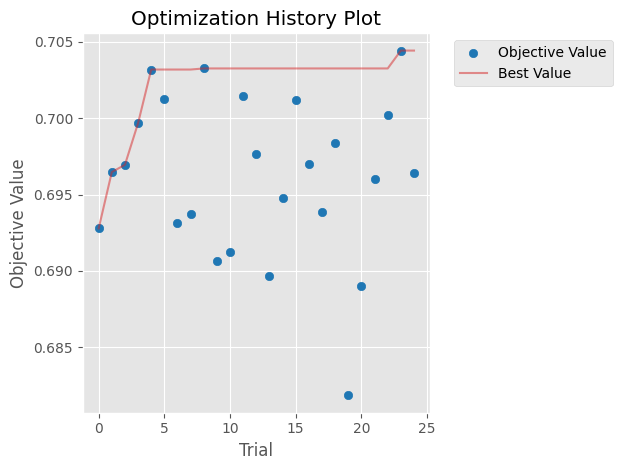

In [15]:
# Визуализация результатов
plot_optimization_history(study)
plt.show()

C:\Users\mikhail.yakunin\AppData\Local\Temp\ipykernel_14492\2945900112.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


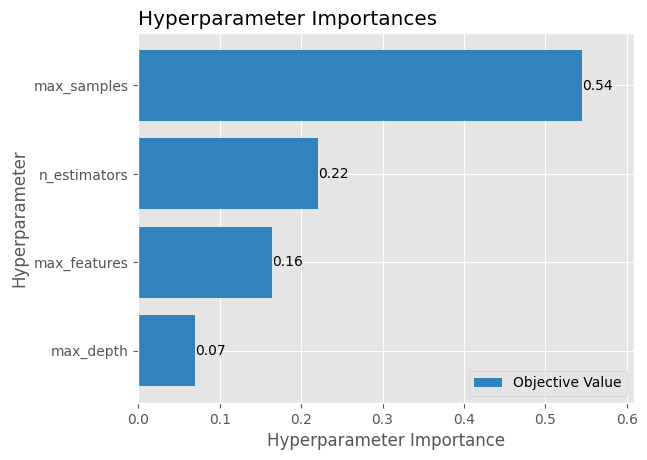

In [17]:
# Визуализация важности параметров
plot_param_importances(study)
plt.show()